# Global Population Analysis (1960–2025)

### Step 1: Libraries and Datasets Import and Data Cleaning

In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Imports and Cleaning

4 distinct datasets were imported which include : pop 2025, pop 1990 - 2024, ISO codes, and region/continent

In [2]:
# Import data set

pop = pd.read_excel('Downloads/Global Population Data/Population(2025).xlsx', sheet_name = 'Sheet1')

# extract and clean columns
pop = pop[['Country (or dependency)', 'Population 2025']]

#Rename column
pop = pop.rename(columns= {'Country (or dependency)':'Country'})
pop = pop.rename(columns= {'Population 2025':'2025'})

# convert and strip Country column
pop['Country'] = pop['Country'].astype(str).str.strip()

pop

,Country,2025
0,India,1463865525
1,China,1416096094
2,United States,347275807
3,Indonesia,285721236
4,Pakistan,255219554
...,...,...
228,Montserrat,4359
229,Falkland Islands,3469
230,Tokelau,2608
231,Niue,1821


-- Import pop 1960 - 2024

In [3]:
# import 1960 - 2024 pop data

pop_2 = pd.read_csv('Downloads/Global Population Data/Population(1960 - 2024).csv')
pop_2

,Country Code,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,Aruba,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,106177.0
1,AFE,Africa Eastern and Southern,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN
2,AFG,Afghanistan,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,43372950.0
3,AFW,Africa Western and Central,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN
4,AGO,Angola,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37804634.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,XKX,Kosovo,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,1152586.0,1187667.0,...,1788274.0,1777568.0,1791019.0,1797086.0,1788891.0,1790152.0,1786080.0,1768096.0,1756366.0,NaN
262,YEM,Yemen,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,6351494.0,6516444.0,...,31159379.0,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,35219853.0
263,ZAF,South Africa,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,19690087.0,20314066.0,...,56723537.0,57259551.0,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,61020221.0
264,ZMB,Zambia,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,3812003.0,3936343.0,...,16399089.0,16914423.0,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,21134695.0


Import ISO data

In [4]:
#  Import and Clean ISO Codes

iso = pd.read_excel('Downloads/Global Population Data/Population(2025).xlsx', sheet_name = 'Sheet2')

# drop iso rows with na
iso.dropna(subset ='3-letter ISO', inplace=True)

# drop unnecessary columns
iso.drop(['Calling Code', '2-letter ISO', '3-digit ISO numeric'], axis = 1, inplace = True)

# rename columns
iso.rename(columns ={'Country (or dependency)':'Country'}, inplace = True)
iso.rename(columns ={'3-letter ISO':'ISO'}, inplace = True)

# remove white space from columns
col = ['Country', 'ISO']
for c in col:
    iso[c] = iso[c].astype(str).str.strip()      # Convert to str and remove white spaces

In [5]:
# left join iso df to pop df (2025 population)

pop_iso = pop.merge(iso, on = 'Country', how = 'left')
pop_iso

,Country,2025,ISO
0,India,1463865525,IND
1,China,1416096094,CHN
2,United States,347275807,USA
3,Indonesia,285721236,IDN
4,Pakistan,255219554,PAK
...,...,...,...
228,Montserrat,4359,MSR
229,Falkland Islands,3469,FLK
230,Tokelau,2608,TKL
231,Niue,1821,NIU


In [6]:
# Check for countries without ISO code

missing_iso_countries = pop_iso.loc[pop_iso['ISO'].isna(), 'Country']

# Update missing ISO codes 

# create a mapping dictionary
iso_updates = {'Guadeloupe' : 'GLP',
              'Martinique' : 'MTQ',
              'French Guiana' : 'GUF',
              'Caribbean Netherlands' : 'BES'}

# Update the iso values for the countries in the iso_updates dict
pop_iso.loc[pop_iso['Country'].isin(iso_updates.keys()), 'ISO'] = pop_iso['Country'].map(iso_updates)

In [7]:
# Right join 
pop_full = pop_2.merge(pop_iso, 
                       left_on= 'Country Code', 
                       right_on= 'ISO', 
                       how= 'right')
pop_full.dropna(subset = 'Country Code', inplace = True)

# drop country name column
pop_full.drop('Country Name', axis= 1, inplace= True)
pop_full.drop('ISO', axis= 1, inplace= True)
pop_full

,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2017,2018,2019,2020,2021,2022,2023,2024,Country,2025
0,IND,435990338.0,446564729.0,457283090.0,468138575.0,479229598.0,490140146.0,500740247.0,511606372.0,522716889.0,...,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.441720e+09,India,1463865525
1,CHN,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,735400000.0,754550000.0,774510000.0,...,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.425179e+09,China,1416096094
2,USA,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,196560000.0,198712000.0,200706000.0,...,3.251221e+08,3.268382e+08,3.283300e+08,3.315269e+08,3.320490e+08,3.332714e+08,3.349149e+08,3.418144e+08,United States,347275807
3,IDN,88296070.0,90791249.0,93375850.0,96051424.0,98833749.0,101365130.0,103792754.0,106526393.0,109450006.0,...,2.673467e+08,2.699518e+08,2.724894e+08,2.748149e+08,2.767581e+08,2.788305e+08,2.811901e+08,2.797980e+08,Indonesia,285721236
4,PAK,45709310.0,46921277.0,48156128.0,49447776.0,50799999.0,52209010.0,53678667.0,55214768.0,56810507.0,...,2.232740e+08,2.269289e+08,2.308009e+08,2.350017e+08,2.394778e+08,2.437007e+08,2.475045e+08,2.452098e+08,Pakistan,255219554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,MHL,14703.0,15219.0,15755.0,16302.0,16852.0,17402.0,17927.0,18655.0,19862.0,...,4.652900e+04,4.528500e+04,4.400700e+04,4.270600e+04,4.136700e+04,4.007700e+04,3.882700e+04,4.241500e+04,Marshall Islands,36282
217,SMR,15428.0,15799.0,16183.0,16580.0,16977.0,17305.0,17523.0,17688.0,17861.0,...,3.382500e+04,3.452200e+04,3.466300e+04,3.477000e+04,3.425200e+04,3.375500e+04,3.386000e+04,3.361400e+04,San Marino,33572
219,PLW,9328.0,9555.0,9793.0,10037.0,10292.0,10547.0,10805.0,10988.0,11080.0,...,1.781200e+04,1.781400e+04,1.779800e+04,1.779200e+04,1.778300e+04,1.775900e+04,1.772700e+04,1.805100e+04,Palau,17663
222,NRU,4607.0,4774.0,4979.0,5226.0,5515.0,5832.0,6043.0,6135.0,6328.0,...,1.132400e+04,1.147700e+04,1.158700e+04,1.164300e+04,1.170900e+04,1.180100e+04,1.187500e+04,1.288400e+04,Nauru,12025


In [8]:
#rearrange column
cols = list(pop_full.columns)

# Remove column from its current poistion
cols.remove('Country')

# Insert region at index 1
cols.insert(1, 'Country')

# Reorder DF
pop_full= pop_full[cols]

pop_full

,Country Code,Country,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,IND,India,435990338.0,446564729.0,457283090.0,468138575.0,479229598.0,490140146.0,500740247.0,511606372.0,...,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.441720e+09,1463865525
1,CHN,China,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,735400000.0,754550000.0,...,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.425179e+09,1416096094
2,USA,United States,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,196560000.0,198712000.0,...,3.230718e+08,3.251221e+08,3.268382e+08,3.283300e+08,3.315269e+08,3.320490e+08,3.332714e+08,3.349149e+08,3.418144e+08,347275807
3,IDN,Indonesia,88296070.0,90791249.0,93375850.0,96051424.0,98833749.0,101365130.0,103792754.0,106526393.0,...,2.646274e+08,2.673467e+08,2.699518e+08,2.724894e+08,2.748149e+08,2.767581e+08,2.788305e+08,2.811901e+08,2.797980e+08,285721236
4,PAK,Pakistan,45709310.0,46921277.0,48156128.0,49447776.0,50799999.0,52209010.0,53678667.0,55214768.0,...,2.201389e+08,2.232740e+08,2.269289e+08,2.308009e+08,2.350017e+08,2.394778e+08,2.437007e+08,2.475045e+08,2.452098e+08,255219554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,MHL,Marshall Islands,14703.0,15219.0,15755.0,16302.0,16852.0,17402.0,17927.0,18655.0,...,4.770900e+04,4.652900e+04,4.528500e+04,4.400700e+04,4.270600e+04,4.136700e+04,4.007700e+04,3.882700e+04,4.241500e+04,36282
217,SMR,San Marino,15428.0,15799.0,16183.0,16580.0,16977.0,17305.0,17523.0,17688.0,...,3.310100e+04,3.382500e+04,3.452200e+04,3.466300e+04,3.477000e+04,3.425200e+04,3.375500e+04,3.386000e+04,3.361400e+04,33572
219,PLW,Palau,9328.0,9555.0,9793.0,10037.0,10292.0,10547.0,10805.0,10988.0,...,1.779700e+04,1.781200e+04,1.781400e+04,1.779800e+04,1.779200e+04,1.778300e+04,1.775900e+04,1.772700e+04,1.805100e+04,17663
222,NRU,Nauru,4607.0,4774.0,4979.0,5226.0,5515.0,5832.0,6043.0,6135.0,...,1.115000e+04,1.132400e+04,1.147700e+04,1.158700e+04,1.164300e+04,1.170900e+04,1.180100e+04,1.187500e+04,1.288400e+04,12025


Import Region Data

In [9]:
# Import region data
region = pd.read_excel('Downloads/Global Population Data/Population(2025).xlsx', sheet_name = 'Sheet3')

# Remove white spaces from country and region
col = ['Country', 'Region']
for c in col:
    region[c] = region[c].astype(str) \
                        .str.strip()

# Extract country and region columns
reg = region[['Country', 'Region']]
reg

,Country,Region
0,India,Asia
1,China,Asia
2,United States,Northern America
3,Indonesia,Asia
4,Pakistan,Asia
...,...,...
190,San Marino,Europe
191,Palau,Oceania
192,Nauru,Oceania
193,Tuvalu,Oceania


In [10]:
# left join pop_iso to region

full_pop = pop_full.merge(reg, on= 'Country', how= 'left')
full_pop

,Country Code,Country,1960,1961,1962,1963,1964,1965,1966,1967,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Region
0,IND,India,435990338.0,446564729.0,457283090.0,468138575.0,479229598.0,490140146.0,500740247.0,511606372.0,...,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.441720e+09,1463865525,Asia
1,CHN,China,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,735400000.0,754550000.0,...,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.425179e+09,1416096094,Asia
2,USA,United States,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,196560000.0,198712000.0,...,3.251221e+08,3.268382e+08,3.283300e+08,3.315269e+08,3.320490e+08,3.332714e+08,3.349149e+08,3.418144e+08,347275807,Northern America
3,IDN,Indonesia,88296070.0,90791249.0,93375850.0,96051424.0,98833749.0,101365130.0,103792754.0,106526393.0,...,2.673467e+08,2.699518e+08,2.724894e+08,2.748149e+08,2.767581e+08,2.788305e+08,2.811901e+08,2.797980e+08,285721236,Asia
4,PAK,Pakistan,45709310.0,46921277.0,48156128.0,49447776.0,50799999.0,52209010.0,53678667.0,55214768.0,...,2.232740e+08,2.269289e+08,2.308009e+08,2.350017e+08,2.394778e+08,2.437007e+08,2.475045e+08,2.452098e+08,255219554,Asia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,MHL,Marshall Islands,14703.0,15219.0,15755.0,16302.0,16852.0,17402.0,17927.0,18655.0,...,4.652900e+04,4.528500e+04,4.400700e+04,4.270600e+04,4.136700e+04,4.007700e+04,3.882700e+04,4.241500e+04,36282,Oceania
210,SMR,San Marino,15428.0,15799.0,16183.0,16580.0,16977.0,17305.0,17523.0,17688.0,...,3.382500e+04,3.452200e+04,3.466300e+04,3.477000e+04,3.425200e+04,3.375500e+04,3.386000e+04,3.361400e+04,33572,Europe
211,PLW,Palau,9328.0,9555.0,9793.0,10037.0,10292.0,10547.0,10805.0,10988.0,...,1.781200e+04,1.781400e+04,1.779800e+04,1.779200e+04,1.778300e+04,1.775900e+04,1.772700e+04,1.805100e+04,17663,Oceania
212,NRU,Nauru,4607.0,4774.0,4979.0,5226.0,5515.0,5832.0,6043.0,6135.0,...,1.132400e+04,1.147700e+04,1.158700e+04,1.164300e+04,1.170900e+04,1.180100e+04,1.187500e+04,1.288400e+04,12025,Oceania


In [11]:
# Fix Inconsistent region names

# Replace value "Northern America' to North America
full_pop.loc[full_pop['Region'] == 'Northern America', 'Region'] = 'North America'

# Replace Latin America with South America
full_pop.loc[full_pop['Region'] == 'Latin America', 'Region'] = 'South America'

In [12]:
# Check for countries with null regions and convert to list

print(full_pop.loc[full_pop['Region'].isna(), 'Country'].tolist())

['Hong Kong', 'Puerto Rico', 'Macao', 'New Caledonia', 'French Polynesia', 'Curaçao', 'Guam', 'Aruba', 'U.S. Virgin Islands', 'Isle of Man', 'Cayman Islands', 'Bermuda', 'Faeroe Islands', 'Greenland', 'Turks and Caicos', 'American Samoa', 'Sint Maarten', 'Northern Mariana Islands', 'Gibraltar', 'British Virgin Islands']


In [13]:
# create a dict with the countries and their regions

con_reg = {
    "Hong Kong": "Asia",
    "Puerto Rico": "North America",
    "Macao": "Asia",
    "New Caledonia": "Oceania",
    "French Polynesia": "Oceania",
    "Curaçao": "North America",
    "Guam": "Oceania",
    "Aruba": "North America",
    "U.S. Virgin Islands": "North America",
    "Isle of Man": "Europe",
    "Cayman Islands": "North America",
    "Bermuda": "North America",
    "Faeroe Islands": "Europe",
    "Greenland": "North America",
    "Turks and Caicos": "North America",
    "American Samoa": "Oceania",
    "Sint Maarten": "North America",
    "Northern Mariana Islands": "Oceania",
    "Gibraltar": "Europe",
    "British Virgin Islands": "North America"
}


# map the dictionary into the full_pop dataframe
full_pop.loc[full_pop['Country'].isin(con_reg.keys()), 'Region'] = full_pop['Country'].map(con_reg)

In [14]:
#rearrange column
cols = list(full_pop.columns)

# Remove column from its current poistion
cols.remove('Region')

# Insert region at index 1
cols.insert(1, 'Region')

full_pop = full_pop[cols]

full_pop

,Country Code,Region,Country,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,IND,Asia,India,435990338.0,446564729.0,457283090.0,468138575.0,479229598.0,490140146.0,500740247.0,...,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.441720e+09,1463865525
1,CHN,Asia,China,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,735400000.0,...,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.425179e+09,1416096094
2,USA,North America,United States,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,196560000.0,...,3.230718e+08,3.251221e+08,3.268382e+08,3.283300e+08,3.315269e+08,3.320490e+08,3.332714e+08,3.349149e+08,3.418144e+08,347275807
3,IDN,Asia,Indonesia,88296070.0,90791249.0,93375850.0,96051424.0,98833749.0,101365130.0,103792754.0,...,2.646274e+08,2.673467e+08,2.699518e+08,2.724894e+08,2.748149e+08,2.767581e+08,2.788305e+08,2.811901e+08,2.797980e+08,285721236
4,PAK,Asia,Pakistan,45709310.0,46921277.0,48156128.0,49447776.0,50799999.0,52209010.0,53678667.0,...,2.201389e+08,2.232740e+08,2.269289e+08,2.308009e+08,2.350017e+08,2.394778e+08,2.437007e+08,2.475045e+08,2.452098e+08,255219554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,MHL,Oceania,Marshall Islands,14703.0,15219.0,15755.0,16302.0,16852.0,17402.0,17927.0,...,4.770900e+04,4.652900e+04,4.528500e+04,4.400700e+04,4.270600e+04,4.136700e+04,4.007700e+04,3.882700e+04,4.241500e+04,36282
210,SMR,Europe,San Marino,15428.0,15799.0,16183.0,16580.0,16977.0,17305.0,17523.0,...,3.310100e+04,3.382500e+04,3.452200e+04,3.466300e+04,3.477000e+04,3.425200e+04,3.375500e+04,3.386000e+04,3.361400e+04,33572
211,PLW,Oceania,Palau,9328.0,9555.0,9793.0,10037.0,10292.0,10547.0,10805.0,...,1.779700e+04,1.781200e+04,1.781400e+04,1.779800e+04,1.779200e+04,1.778300e+04,1.775900e+04,1.772700e+04,1.805100e+04,17663
212,NRU,Oceania,Nauru,4607.0,4774.0,4979.0,5226.0,5515.0,5832.0,6043.0,...,1.115000e+04,1.132400e+04,1.147700e+04,1.158700e+04,1.164300e+04,1.170900e+04,1.180100e+04,1.187500e+04,1.288400e+04,12025


### EXPLORATORY DATA ANALYSIS (EDA) And Data Visualization

#### Population Growth Rate By Region

In [15]:
# group by continent

year_cols= [str(y) for y in range(1960, 2026)]

pop_by_region = full_pop.groupby('Region')[year_cols].sum()

# calculate yearly growth rate
growth_rate = pop_by_region.pct_change(axis=1) * 100


#  Unpivot table
growth_long = growth_rate.reset_index().melt(
    id_vars='Region',
    var_name='Year',
    value_name='GrowthRate'
)

growth_long

,Region,Year,GrowthRate
0,Africa,1960,NaN
1,Asia,1960,NaN
2,Europe,1960,NaN
3,North America,1960,NaN
4,Oceania,1960,NaN
...,...,...,...
391,Asia,2025,1.530461
392,Europe,2025,-0.112371
393,North America,2025,1.676755
394,Oceania,2025,1.349433


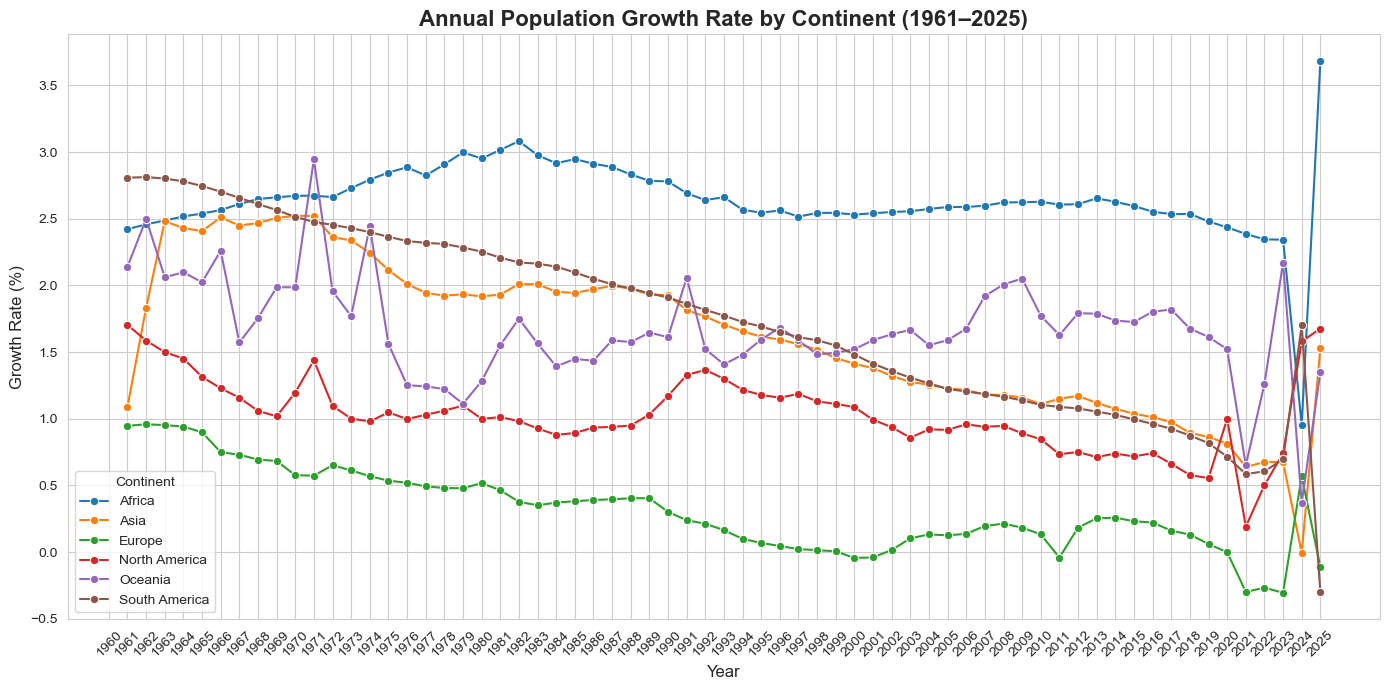

In [16]:
# Visualization
plt.figure(figsize=(14,7))
sns.set_style("whitegrid")

sns.lineplot(
    data=growth_long,
    x='Year',
    y='GrowthRate',
    hue='Region',
    marker='o'
)

plt.title('Annual Population Growth Rate by Continent (1961–2025)', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.legend(title='Continent', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Downloads/Charts/Annual Population Growth Rate by Continent (1961-2025).png", dpi=300, bbox_inches="tight")
plt.show()


#### Poulation By Region (2025)

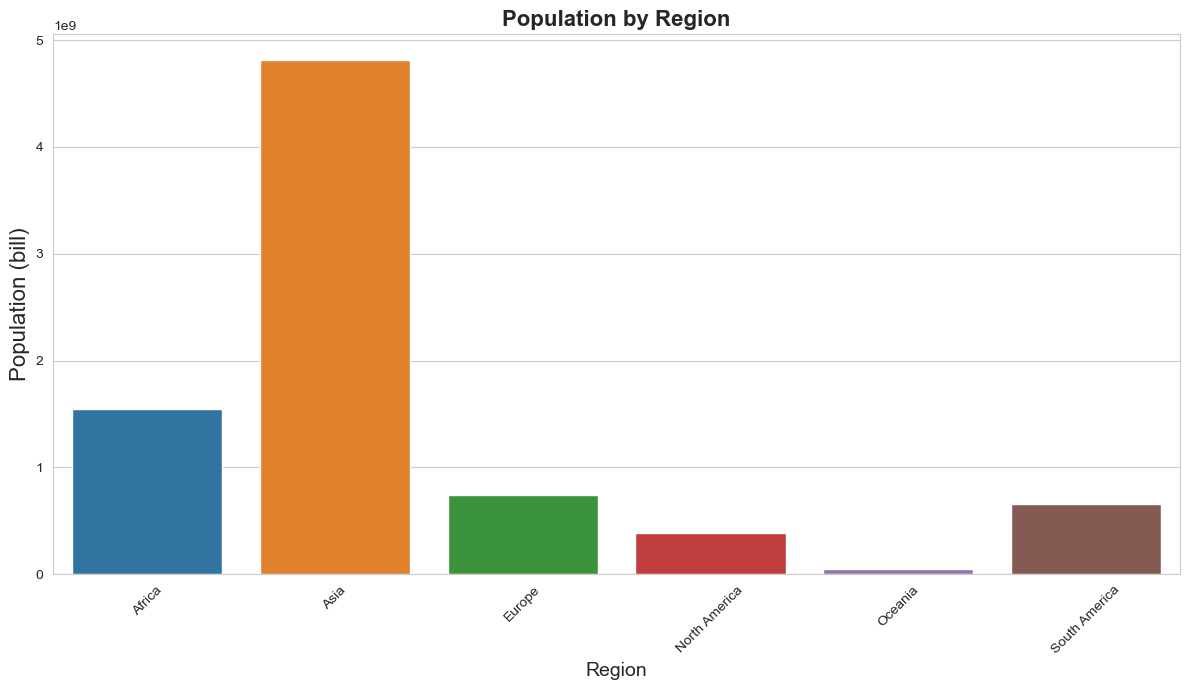

In [17]:
# Population by region

# Group 2025 population by region
grouped = full_pop.groupby('Region')['2025'].sum().reset_index()


# Visualization
plt.figure(figsize =(12, 7))
sns.barplot(
        data= grouped,
        x= 'Region',
        y= '2025',
        hue= 'Region')

plt.title('Population by Region', fontsize=16, weight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Population (bill)', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Downloads/Charts/Population by Region.png", dpi=300, bbox_inches="tight")
plt.show()

#### Top 10 Most Populated Country (2025)

<Figure size 1500x500 with 0 Axes>

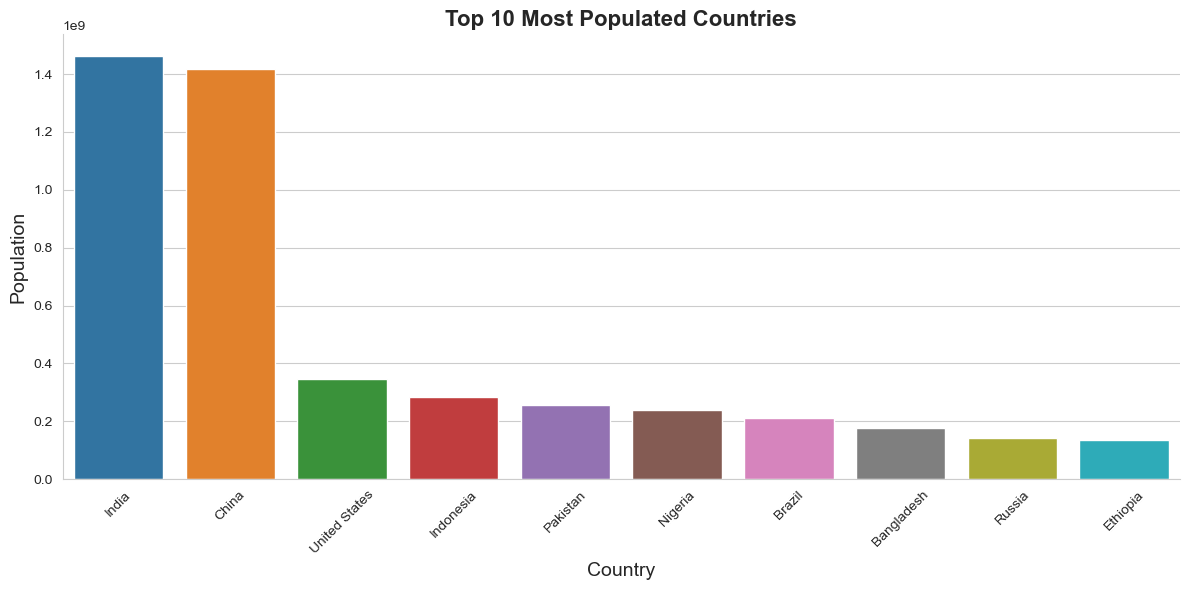

In [18]:
# Top 10 most populated country

top_10_mp = full_pop.loc[:, ['Country', '2025']].sort_values('2025', ascending= False).head(10)
top_10_mp

# Visulization
plt.figure(figsize=(15, 5))
sns.catplot(
            data= top_10_mp,
            x= 'Country',
            y= '2025',
            kind= 'bar',
            hue= 'Country',
            height= 6,
            aspect= 2)

plt.title('Top 10 Most Populated Countries', fontsize= 16, weight= 'bold')
plt.xlabel('Country', fontsize= 14)
plt.ylabel('Population', fontsize= 14)
plt.xticks(rotation= 45)
plt.tight_layout()
plt.savefig("Downloads/Charts/Top 10 Most Populated Countries", dpi=300, bbox_inches="tight")
plt.show()

#### Top 10 Least Populated Country (2025)

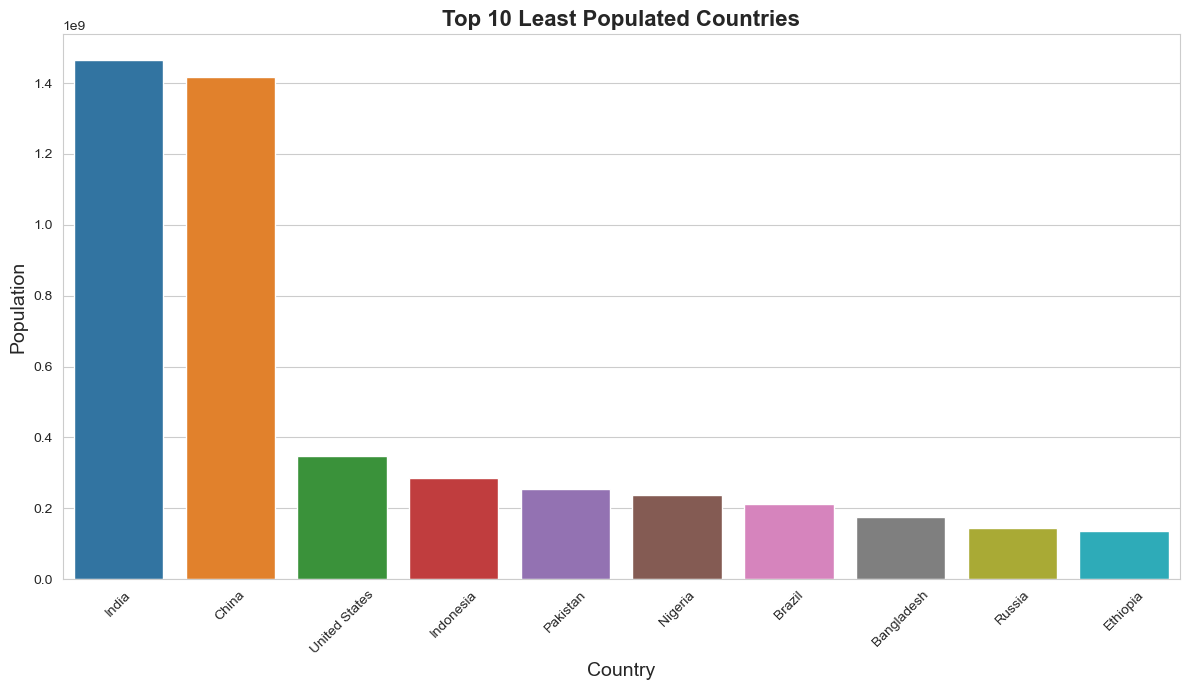

In [19]:
# Top 10 least populated country

top_10_lp = full_pop.loc[:, ['Country', '2025']].sort_values('2025', ascending= True).head(10)
top_10_lp

# Visulization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.barplot(
            data= top_10_mp,
            x= 'Country',
            y= '2025',
            hue= 'Country')

plt.title('Top 10 Least Populated Countries', fontsize= 16, weight= 'bold')
plt.xlabel('Country', fontsize= 14)
plt.ylabel('Population', fontsize= 14)
plt.xticks(rotation= 45)
plt.tight_layout()
plt.savefig("Downloads/Charts/Top 10 Least Populated Countries", dpi=300, bbox_inches="tight")
plt.show()

#### Top 10 Most Populated countries in each Region (2025)

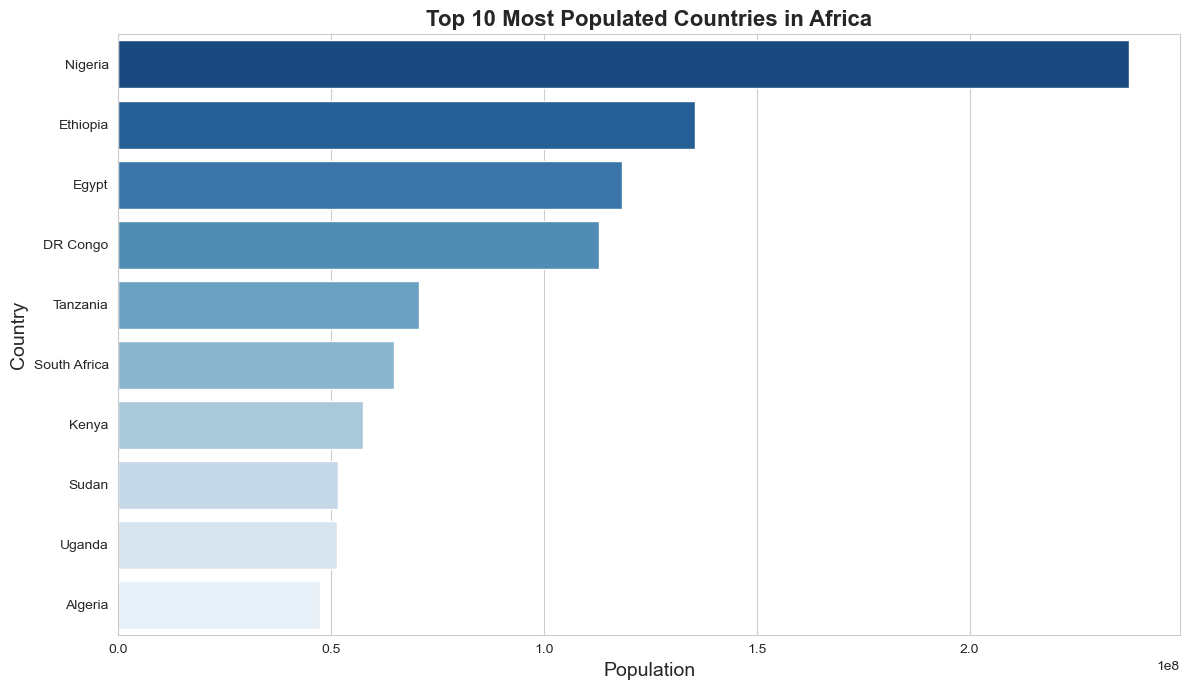

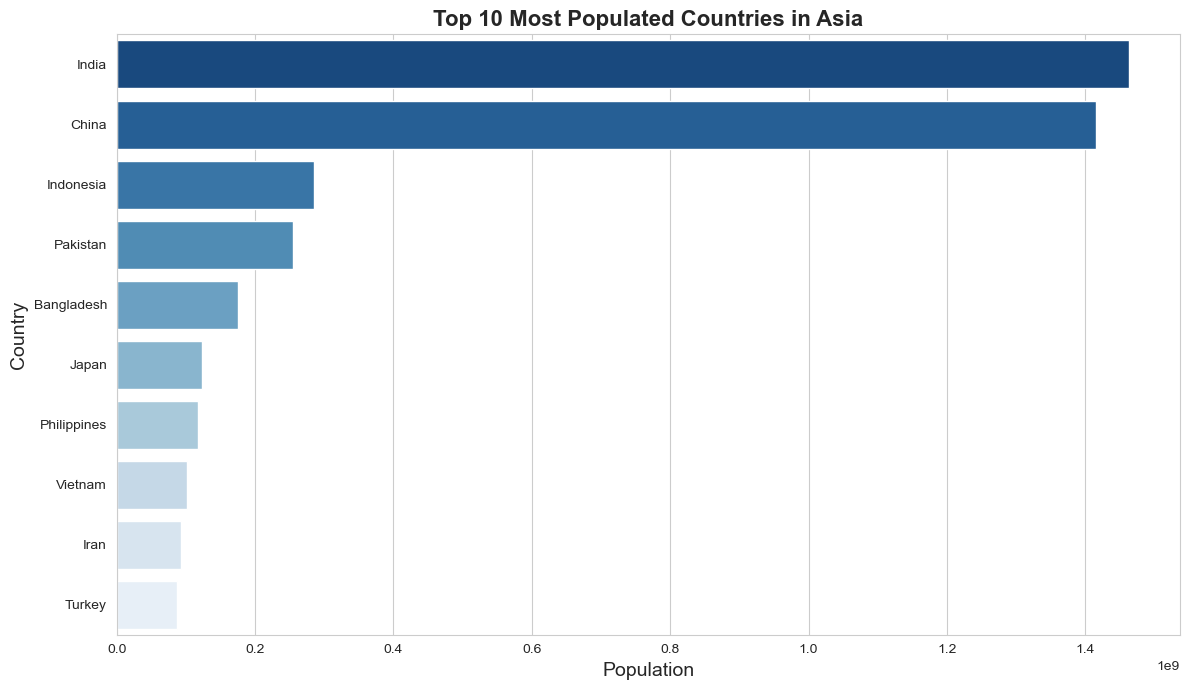

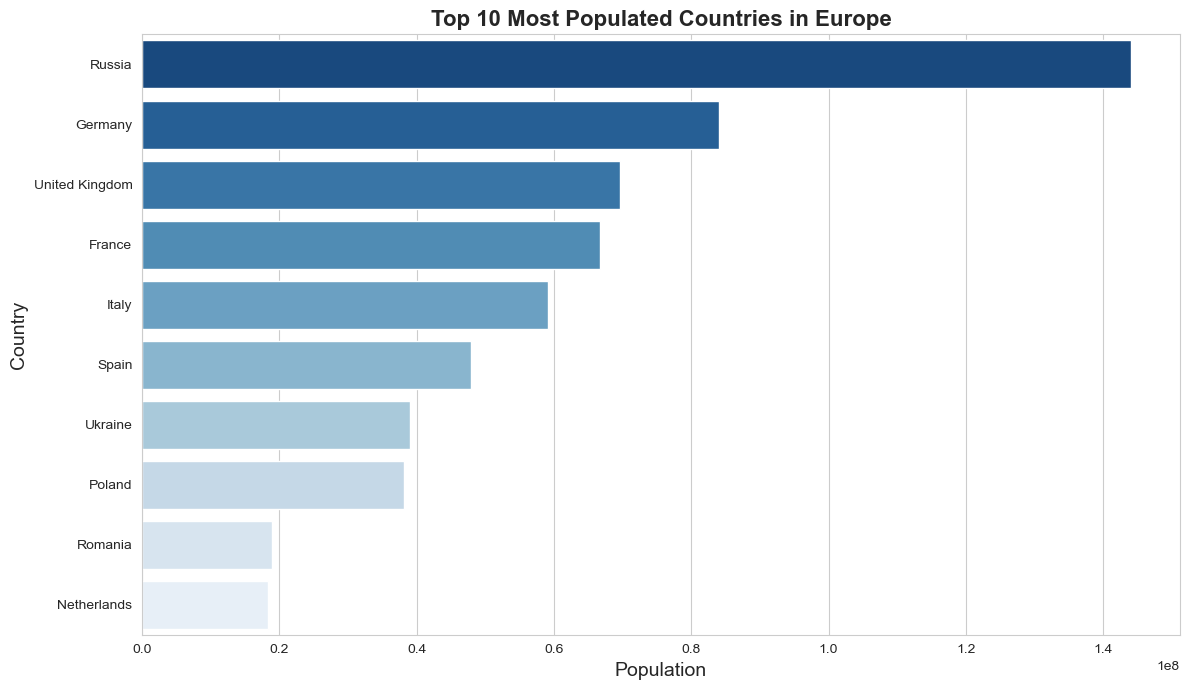

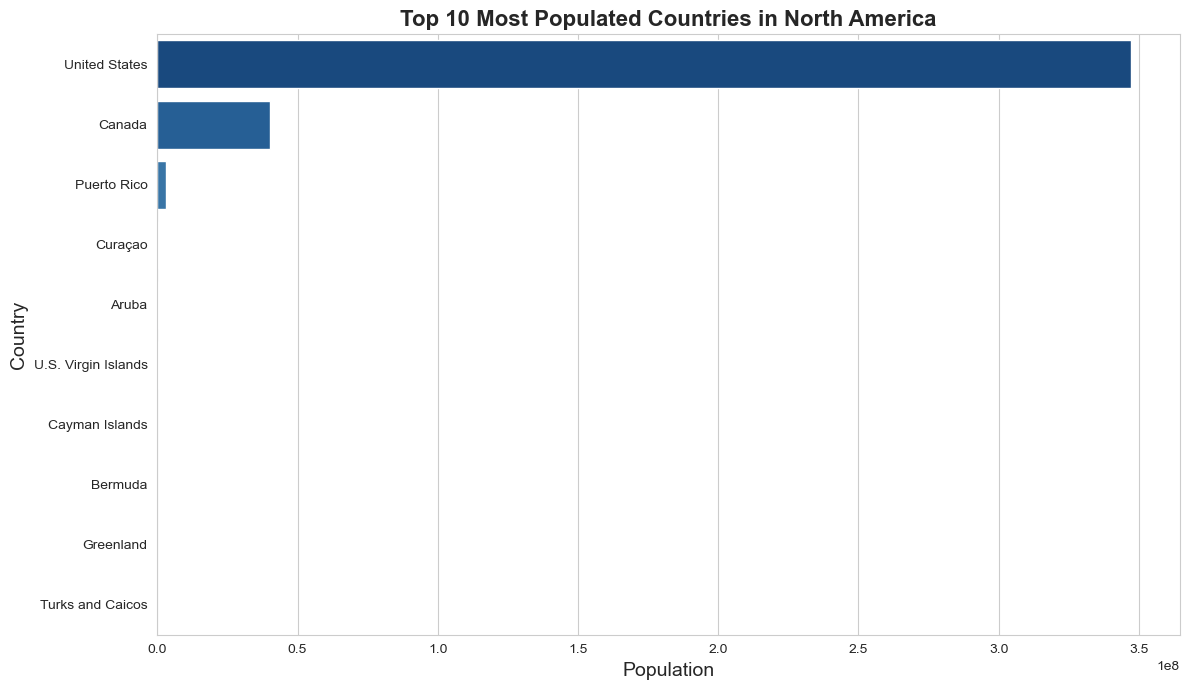

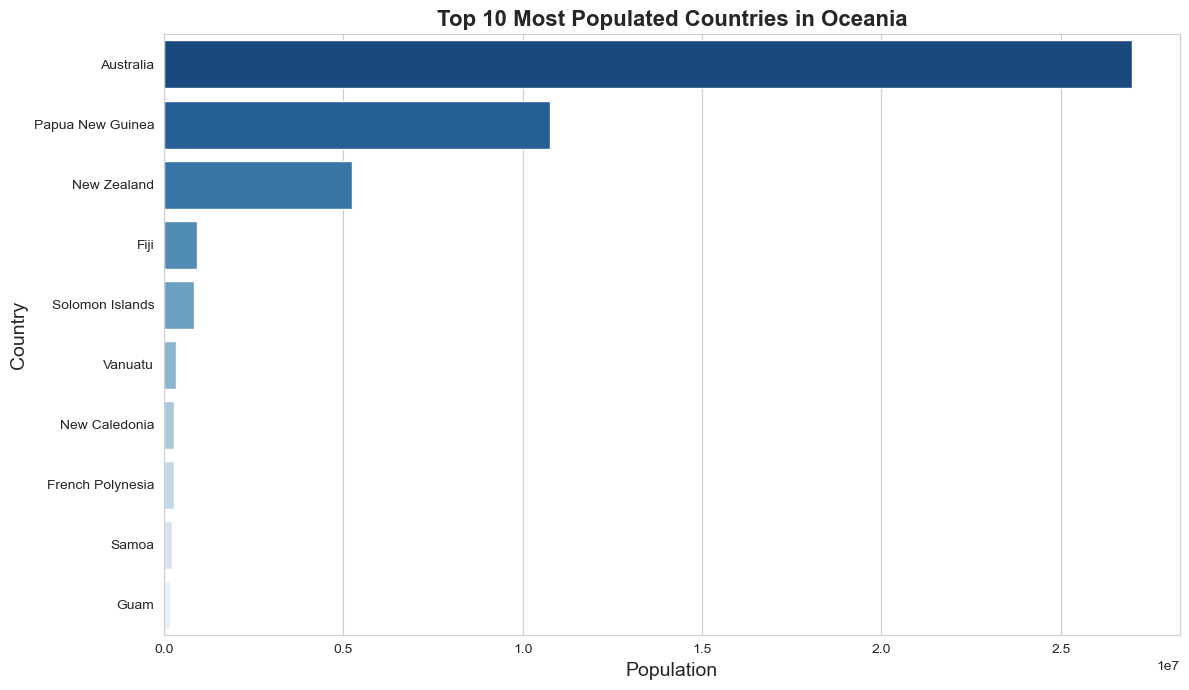

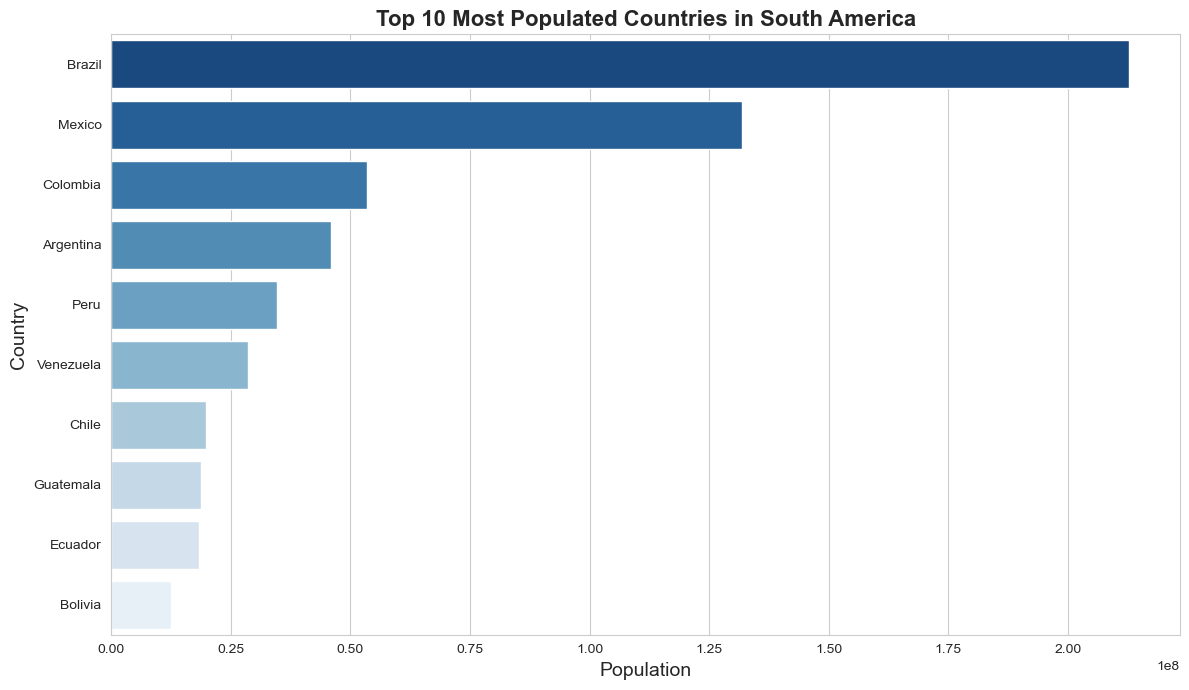

In [20]:
# Top 10 Most Populated countries in each Region

for region, group in full_pop.groupby('Region'):
    top_10 = group.sort_values('2025', ascending= False).head(10)

    sns.set_palette(sns.color_palette("Blues", n_colors=10))
    plt.figure(figsize= (12, 7))
    sns.barplot(data= top_10,
                x = '2025', 
                y= 'Country', 
                hue= 'Country',
                hue_order= top_10.sort_values('2025', ascending=True)['Country'].tolist())
    plt.title(f"Top 10 Most Populated Countries in {region}", fontsize= 16, weight= 'bold')
    plt.ylabel('Country', fontsize= 14)
    plt.xlabel('Population', fontsize= 14)
    plt.tight_layout()
    plt.savefig(f"Downloads/Charts/top10 population {region}.png", dpi=300, bbox_inches="tight")
    plt.show()

#### Top 10 least Populated countries in each Region (2025)

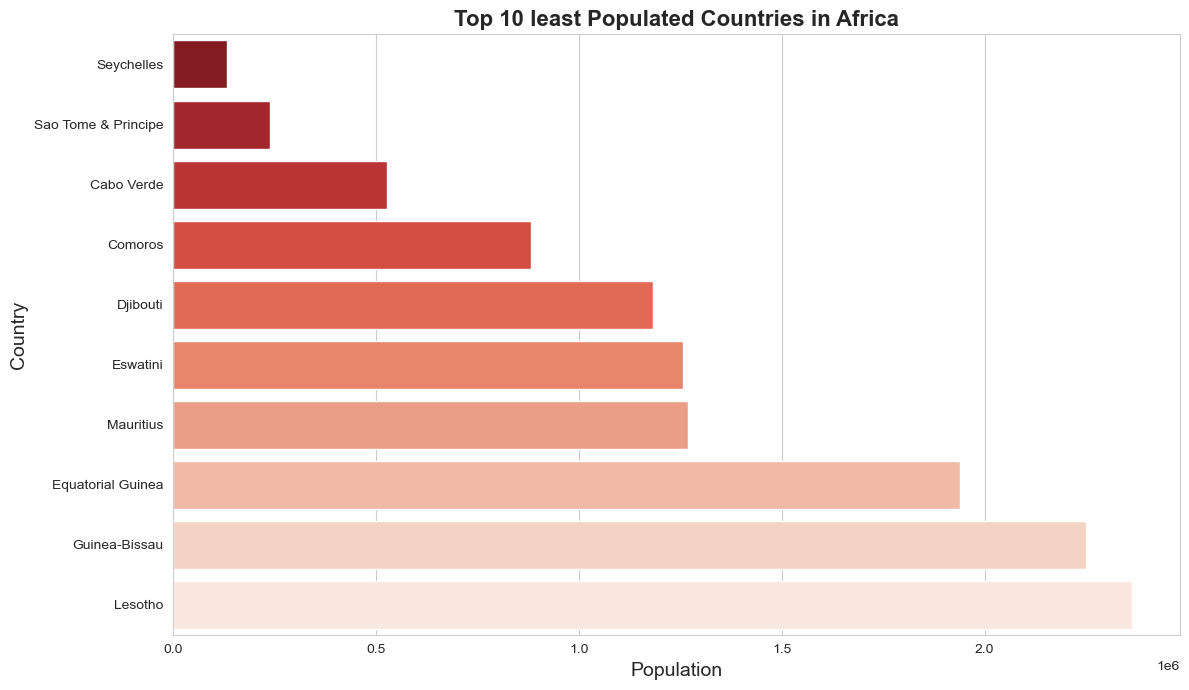

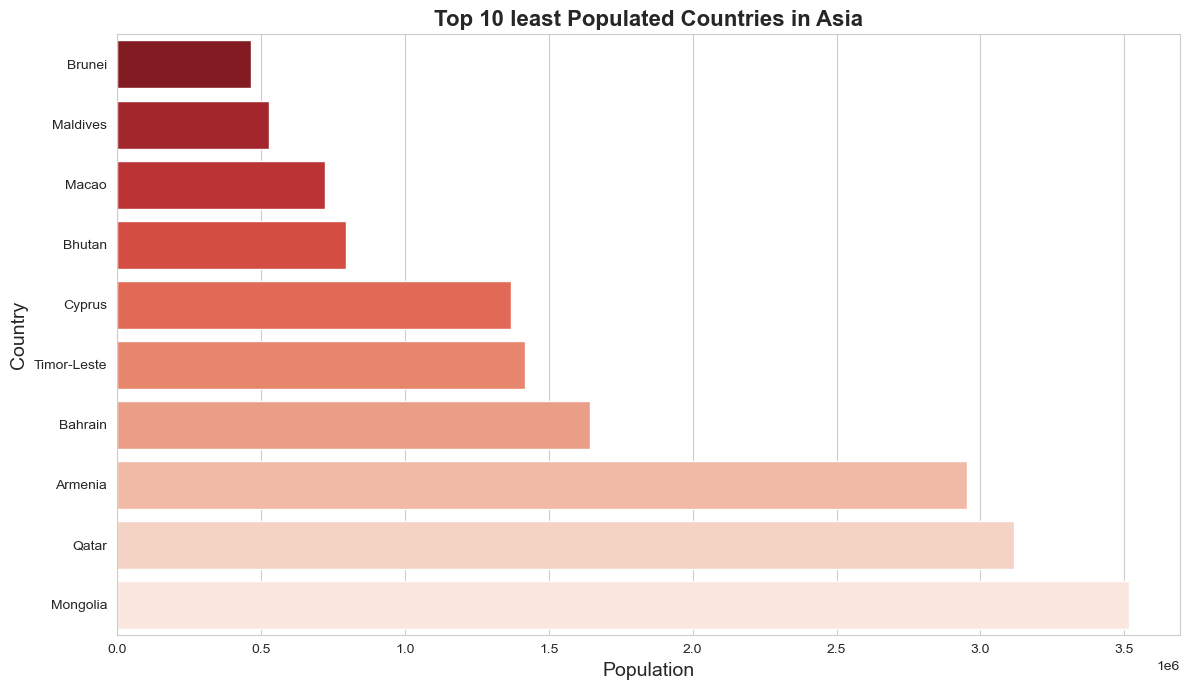

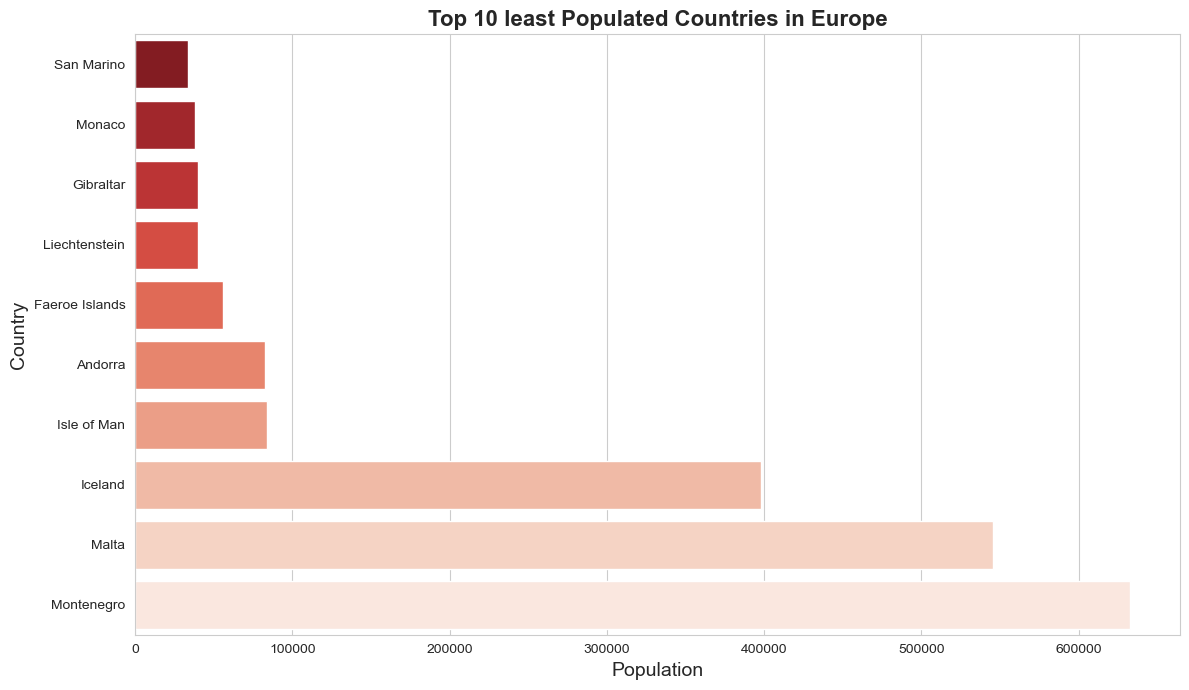

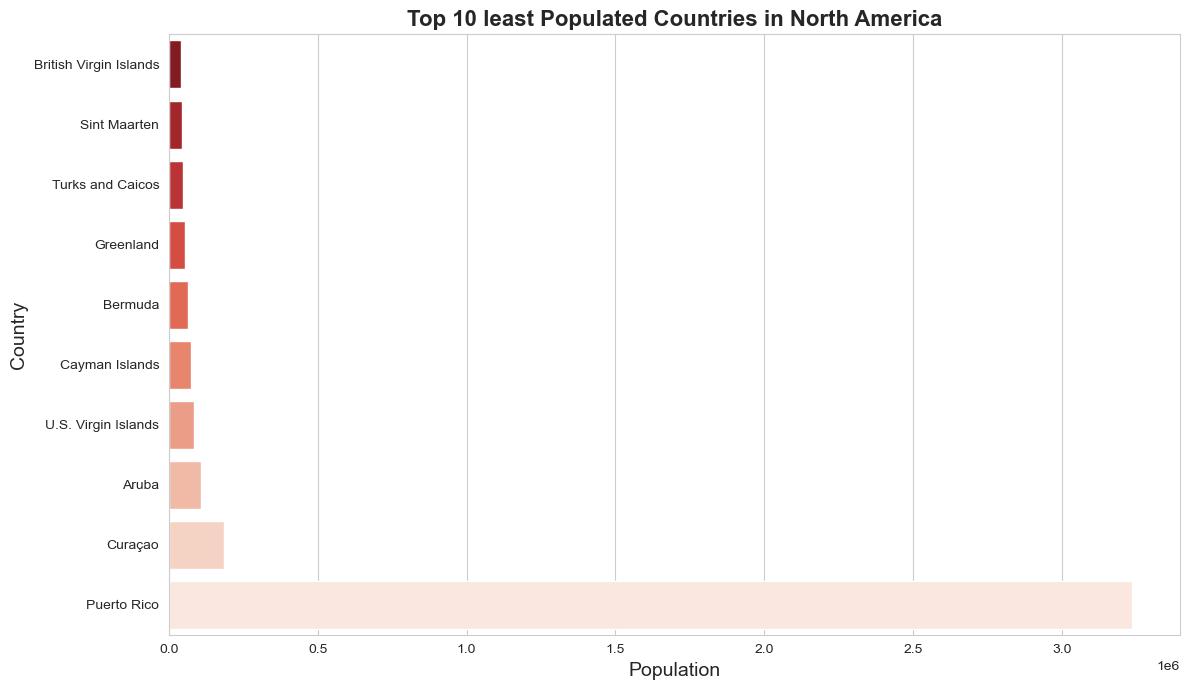

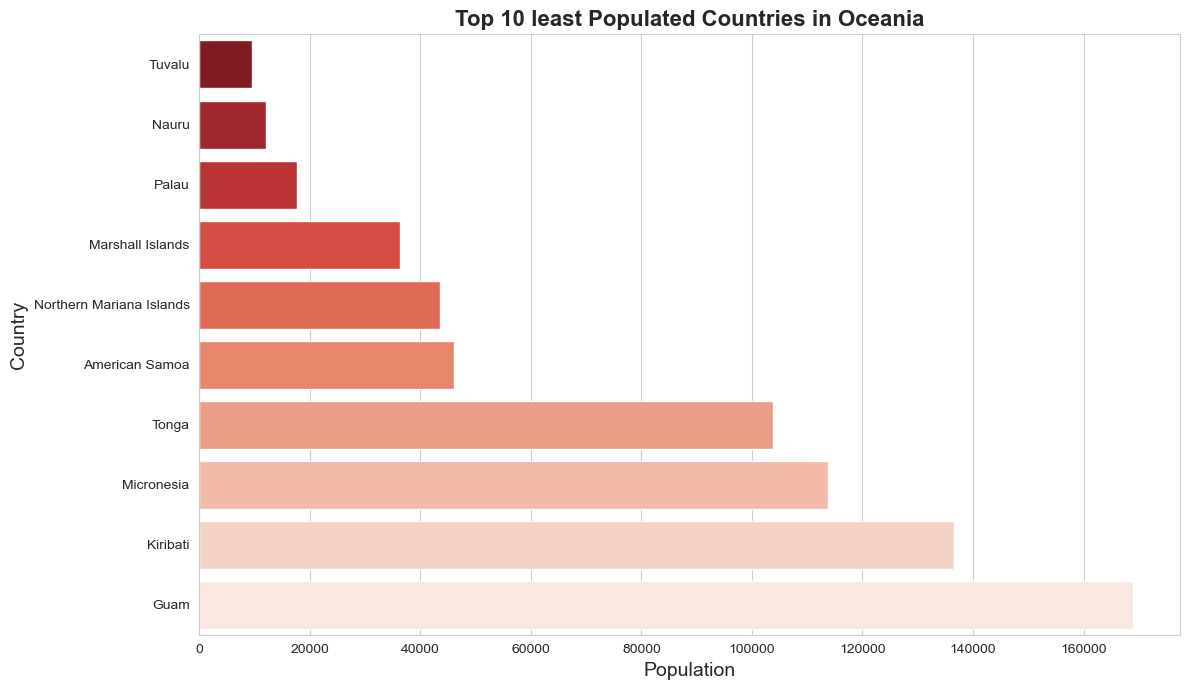

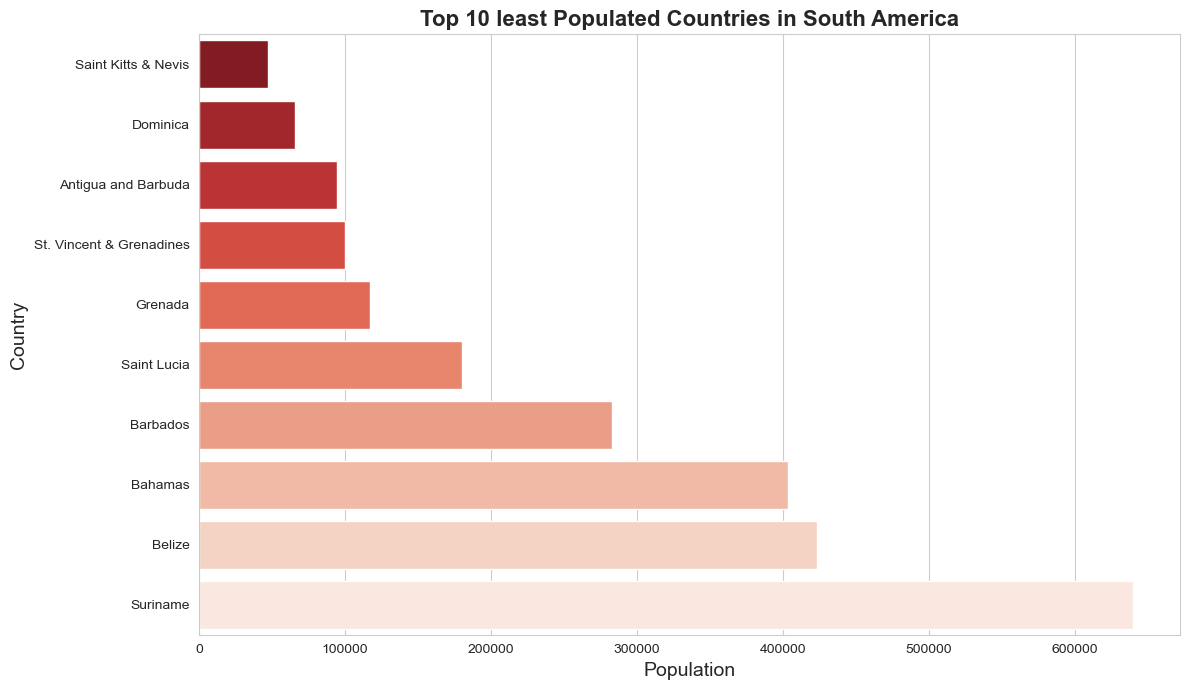

In [21]:
# Top 10 least Populated countries in each Region

for region, group in full_pop.groupby('Region'):
    top_10 = group.sort_values('2025', ascending= True).head(10)

    
    sns.set_palette(sns.color_palette("Reds", n_colors=10))
    plt.figure(figsize= (12, 7))
    sns.barplot(data= top_10,
                x = '2025', 
                y= 'Country',
               hue = 'Country',
               hue_order= top_10.sort_values('2025', ascending=False)['Country'].tolist())
    plt.title(f"Top 10 least Populated Countries in {region}", fontsize= 16, weight= 'bold')
    plt.ylabel('Country', fontsize= 14)
    plt.xlabel('Population', fontsize= 14)
    plt.tight_layout()
    plt.savefig(f"Downloads/Charts/Least10 population {region}.png", dpi=300, bbox_inches="tight")
    plt.show()